<a href="https://colab.research.google.com/github/serenacervio/TP1-SistemasdeIA/blob/main/TP1SIA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **TP1 - Sistemas de Inteligencia Artificial**
## Regresión con Modelos Lineales
#### Dataset: Properati Bs. As. 2020 ([Kaggle](https://www.kaggle.com/datasets/alejandromendivil/bsas-realstate-on-sale/))

 **Trabjaremos con modelos lineales**

Son aquellos que tienen la forma:

$\hat{y} =\theta_0 +\theta_1 x_1 + \theta_2 x_2 + .. +\theta_n x_n$

o, vectorialmente

$\hat{y} = \vec{\theta} \cdot \vec{x}$

donde $\hat{y}$ es la predicción,
$n$ es el número de _features_ o variables predictoras, $x_i$ es el i-ésimo feature y $\vec{\theta}$ es el vector de parámetros o _pesos_ del modelo (lo que entrenamos).

**Modelos lineales regularizados**

En los modelos lineales simples, los parámetros $\theta_i$ se ajustan minimizando el error cuadrático medio entre las predicciones y los valores reales. Sin embargo, cuando hay **muchas variables**, correlaciones fuertes entre ellas o riesgo de *overfitting*, se utilizan **términos de regularización** que penalizan la magnitud de los coeficientes, mejorando así la capacidad de generalización del modelo.

Algunos ejemplos:

- **Ridge Regression** (*L2 regularization*):  

  $\text{Loss} = \text{MSE} + \alpha \sum_{i=1}^n \theta_i^2$

  Tiende a mantener todos los coeficientes pequeños pero distintos de cero.

- **Lasso Regression** (*L1 regularization*):  

  $\text{Loss} = \text{MSE} + \alpha \sum_{i=1}^n |\theta_i|$

  Puede forzar coeficientes exactamente a cero, funcionando también como método de selección de variables.

- **Elastic Net**: combina L1 y L2, balanceando sus ventajas.


**Modelos lineales con *features* polinomiales**

Los modelos lineales pueden extenderse para capturar relaciones **no lineales** entre las variables de entrada y la variable objetivo mediante la creación de nuevas variables que son **combinaciones polinomiales** de las originales.

Por ejemplo, con dos variables $x_1$ y $x_2$ y un polinomio de grado 2, el modelo considera:  
$
\hat{y} = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \theta_3 x_1^2 + \theta_4 x_2^2 + \theta_5 x_1 x_2
$  

Aunque la relación entre las *features* y $\hat{y}$ puede ser no lineal, el modelo sigue siendo **lineal en los parámetros** $\theta_i$, por lo que conserva las propiedades y métodos de ajuste de los modelos lineales clásicos.

Este enfoque, combinado con regularización, permite capturar patrones complejos sin perder el control sobre el sobreajuste.


------------------------
------------------------
**Instrucciones:**

- **No** modificar las celdas de texto.

- Resolver cada consigna en su sección correspondiente. Pueden sumar celdas de código y texto si lo consideran necesario. Recuerden que lo más importante es el razonamiento y justificación de los pasos para demostrar comprensión del problema a resolver.

- **ENTREGA:** Ir a Archivo > Descargar .ipynb. Este archivo .ipynb deberán subirlo al campus junto con las diapositivas en formato PDF (archivo no editable) hasta las 23:59hs del día anterior a la presentación. La presentación oral de este último documento será de manera grupal en hasta 10 minutos el día 10/09 durante el horario de clase (se sorteará el orden de los grupos al azar). Dado el tiempo de exposición, recomendamos un máximo de 5 diapositivas.

------------------------
------------------------

# 1. Importar librerías

In [ ]:
# las librerías escenciales
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 2. Definir el problema

- **¿Cuál es la tarea que queremos hacer con aprendizaje automático?**
  - Predecir el precio de las propiedades.
- **¿Qué métrica de evaluación vamos a usar?**
  - Utilizaremos el RMSE (_root mean squared error_).


# 3. Cargar los datos

In [ ]:
# Cargamos el dataset de Kaggle
import kagglehub
import os

path = kagglehub.dataset_download("alejandromendivil/bsas-realstate-on-sale")
csv_file_path = os.path.join(path, 'bsas_realstate_on_sale_properati_dataset_2020.csv')

df = pd.read_csv(csv_file_path) # lo guardamos en un DataFrame de pandas

Using Colab cache for faster access to the 'bsas-realstate-on-sale' dataset.


# 4.  Análisis exploratorio de datos

Acá comienzan ustedes..
- 4.1) **Conocer los datos**
  - Explorar la estructura del dataset: cantidad de columnas y filas, tipos de datos, entender qué significa cada variable (métodos relevantes: `head()`, `info()`, `describe()`).

- 4.2) **Valores faltantes**
  - Calcular el porcentaje de valores nulos por columna.
  - Decidir si se imputan, se eliminan o se dejan según la estrategia de preprocesamiento.

- 4.3) **Distribuciones de variables y valores atípicos**
  - Graficar histogramas, boxplots o violinplots para variables numéricas.
  - Identificar valores atípicos y limpiarlos de ser necesario.
  - Graficar conteos para variables categóricas (sug: `value_counts()` o `sns.countplot()`).

- 4.4) **Relaciones entre variables**
  - Graficar diagramas de dispersión entre variables relevantes y el precio (sug: `scatterplot()`, `sns.pairplot()`).
  - Calcular matriz de correlación y visualizar (sug: `imshow` o `sns.heatmap()`).

In [ ]:
# su código
#4.1
df.head()

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
0,2019-10-17,2019-12-23,2019-10-17,-34.605880,-58.384949,Argentina,Capital Federal,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,USD,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,Venta
1,2019-10-17,2019-11-21,2019-10-17,-34.624056,-58.412110,Argentina,Capital Federal,Boedo,2.0,1.0,2.0,70.0,58.0,159000.0,USD,Espectacular PH reciclado en Boedo sin expensas.,PH reciclado en Boedo a una cuadra de la plaz...,PH,Venta
2,2019-10-17,2019-11-01,2019-10-17,-34.593569,-58.427474,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,45.0,45.0,125000.0,USD,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",PH,Venta
3,2019-10-17,2019-12-23,2019-10-17,-34.581294,-58.436754,Argentina,Capital Federal,Palermo,2.0,1.0,1.0,85.0,50.0,295000.0,USD,COSTA RICA 5800 / PALERMO HOLLYWOOD / VENTA PH...,HERMOSO PH EN PALERMO!!!2 AMBIENTES TOTALMENTE...,PH,Venta
4,2019-10-17,2020-03-11,2019-10-17,-34.914194,-57.938219,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,2.0,1.0,1.0,50.0,35.0,40000.0,USD,58 entre 1 y 2 Venta de departamento en ph.1 ...,58 entre 1 y 2 Venta de departamento en PH. P...,PH,Venta


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146660 entries, 0 to 146659
Data columns (total 19 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   start_date       146660 non-null  object 
 1   end_date         146660 non-null  object 
 2   created_on       146660 non-null  object 
 3   lat              136735 non-null  float64
 4   lon              136701 non-null  float64
 5   l1               146660 non-null  object 
 6   l2               146660 non-null  object 
 7   l3               146660 non-null  object 
 8   rooms            146660 non-null  float64
 9   bedrooms         146660 non-null  float64
 10  bathrooms        140703 non-null  float64
 11  surface_total    126133 non-null  float64
 12  surface_covered  125046 non-null  float64
 13  price            146660 non-null  float64
 14  currency         146660 non-null  object 
 15  title            146660 non-null  object 
 16  description      146660 non-null  obje

In [ ]:
df.describe()

,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,136735.000000,136701.000000,146660.000000,146660.000000,140703.000000,126133.000000,125046.000000,1.466600e+05
mean,-34.604896,-58.465304,3.079817,1.983240,1.599994,216.872888,112.818011,2.412211e+05
std,0.468428,0.486190,1.416352,1.151304,0.889324,2037.606649,916.857584,3.185195e+05
min,-35.318457,-180.000000,1.000000,0.000000,1.000000,10.000000,1.000000,5.500000e+03
25%,-34.627667,-58.504012,2.000000,1.000000,1.000000,52.000000,47.000000,1.110000e+05
50%,-34.600943,-58.443262,3.000000,2.000000,1.000000,78.000000,68.000000,1.660000e+05
75%,-34.574600,-58.407586,4.000000,3.000000,2.000000,140.000000,108.000000,2.650000e+05
max,85.051129,-57.805832,35.000000,15.000000,14.000000,193549.000000,126062.000000,3.243423e+07


In [ ]:
df.tail()

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
146655,2019-07-31,2019-08-13,2019-07-31,-34.816348,-58.181963,Argentina,Bs.As. G.B.A. Zona Sur,Berazategui,2.0,1.0,1.0,54.0,48.0,165000.0,USD,Departamento en Venta en Barrio Privado Barran...,Departamento de 2 ambientesCocina con alacena ...,Departamento,Venta
146656,2019-07-31,2019-08-14,2019-07-31,-34.446459,-58.937810,Argentina,Bs.As. G.B.A. Zona Norte,Pilar,4.0,3.0,2.0,164.0,90.0,130000.0,USD,Venta departamentos tres dormitorios jardín co...,Muy buen duplex a estrenar en dos plantas más ...,Departamento,Venta
146657,2019-07-31,2019-08-14,2019-07-31,-34.444633,-58.981606,Argentina,Bs.As. G.B.A. Zona Norte,Pilar,1.0,1.0,1.0,50.0,35.0,73000.0,USD,Venta departamento de un ambiente Manzanares C...,"En los Condominios de Campo Manzanares Chico, ...",Departamento,Venta
146658,2019-07-31,2019-08-14,2019-07-31,-34.444830,-58.981796,Argentina,Bs.As. G.B.A. Zona Norte,Pilar,2.0,1.0,1.0,38.0,38.0,68000.0,USD,Departamento en Venta. Manzanares chico.,Broker: Maria 11Departamento de dos ambientes ...,Departamento,Venta
146659,2019-07-31,2019-10-12,2019-07-31,-34.444760,-58.981885,Argentina,Bs.As. G.B.A. Zona Norte,Pilar,3.0,2.0,1.0,75.0,75.0,98000.0,USD,Departamento en venta en Manzanares Chico,"Departamento en el Barrio Manzanares Chico , e...",Departamento,Venta


In [ ]:
# 4.2 Calcular el porcentaje de valores nulos por columna.
#Decidir si se imputan, se eliminan o se dejan según la estrategia de preprocesamiento.
null_percentages = df.isnull().sum() / len(df) * 100
print("porcentaje_nulos_x_columna")
display(null_percentages.to_frame('Porcentaje de Nulos').T)

porcentaje_nulos_x_columna


,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
Porcentaje de Nulos,0.0,0.0,0.0,6.767353,6.790536,0.0,0.0,0.0,0.0,0.0,4.061776,13.996318,14.737488,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#promedio, mediana y la variabilidad de surface_covered según la cantidad de rooms
surface_by_rooms = df[df['surface_covered'].notna()].groupby('rooms')['surface_covered'].agg(['mean', 'median', 'std'])
display(surface_by_rooms)

,mean,median,std
rooms,,,
1.0,49.530852,34.0,306.097178
2.0,54.914885,44.0,197.364738
3.0,93.834186,69.0,833.142992
4.0,145.347468,110.0,892.149813
5.0,243.076528,164.0,2180.532265
6.0,297.962410,219.0,1524.548973
7.0,323.766730,255.0,1136.716021
8.0,319.996026,281.0,190.733225
9.0,363.135514,312.0,219.007504


In [ ]:
surface_covered_by_bedrooms = df[df['surface_covered'].notna()].groupby('bedrooms')['surface_covered'].agg(['mean', 'median', 'std'])
display(surface_by_rooms)

,mean,median,std
rooms,,,
1.0,49.530852,34.0,306.097178
2.0,54.914885,44.0,197.364738
3.0,93.834186,69.0,833.142992
4.0,145.347468,110.0,892.149813
5.0,243.076528,164.0,2180.532265
6.0,297.962410,219.0,1524.548973
7.0,323.766730,255.0,1136.716021
8.0,319.996026,281.0,190.733225
9.0,363.135514,312.0,219.007504


In [ ]:
def impute_surfaces(df,
                    keys_levels=[
                        ['bedrooms','rooms'],  # grupo más específico
                        ['bedrooms'],              # solo dormitorios
                        ['rooms']              # solo rooms
                    ]):

    # Paso 1: si falta total pero tengo covered → total = covered
    df['surface_total'] = df['surface_total'].fillna(df['surface_covered'])
    # Si falta covered pero tengo total → covered = total
    df['surface_covered'] = df['surface_covered'].fillna(df['surface_total'])

    # Paso 2: imputación en cascada con medianas por grupos de rooms
    for keys in keys_levels:
        med = df.groupby(keys, dropna=False)[['surface_total','surface_covered']].transform('median')
        df['surface_total']   = df['surface_total'].fillna(med['surface_total'])
        df['surface_covered'] = df['surface_covered'].fillna(med['surface_covered'])

    # Paso 3: último recurso → mediana global
    df['surface_total']   = df['surface_total'].fillna(df['surface_total'].median())
    df['surface_covered'] = df['surface_covered'].fillna(df['surface_covered'].median())

    # Paso 4: consistencia (covered <= total)
    df['surface_covered'] = np.minimum(df['surface_covered'], df['surface_total'])

    return df

df = impute_surfaces(df) # Assign the result back to df

In [ ]:
null_percentages = df.isnull().sum() / len(df) * 100
print("porcentaje_nulos_x_columna")
display(null_percentages.to_frame('Porcentaje de Nulos').T)

porcentaje_nulos_x_columna


,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
Porcentaje de Nulos,0.0,0.0,0.0,6.767353,6.790536,0.0,0.0,0.0,0.0,0.0,4.061776,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
#4.3 Distribuciones de variables y valores atípicos
#Graficar histogramas, boxplots o violinplots para variables numéricas.
#Identificar valores atípicos y limpiarlos de ser necesario.
#Graficar conteos para variables categóricas (sug: value_counts() o sns.countplot()).
import matplotlib.pyplot as plt
import seaborn as sns

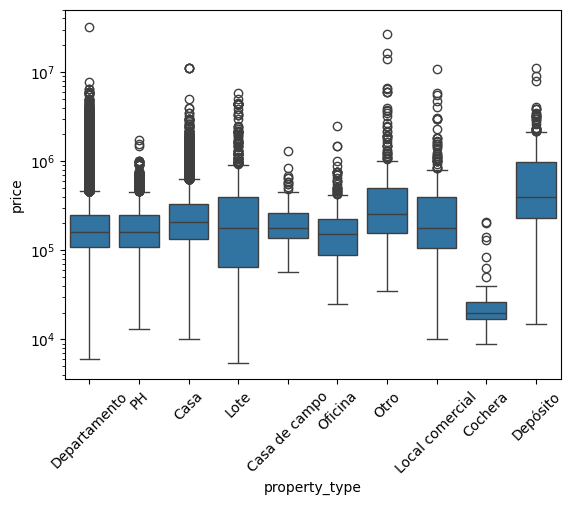

In [ ]:
# Boxplot: precio según tipo de propiedad
sns.boxplot(data=df, x="property_type", y="price")
plt.xticks(rotation=45)
plt.yscale('log') # Set y-axis to a logarithmic scale
plt.show()

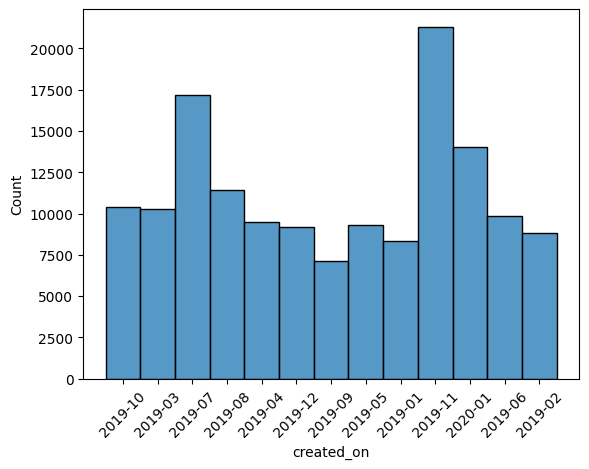

In [ ]:
# Histograma de fechas (ejemplo: propiedades creadas por mes)
df["created_on"] = pd.to_datetime(df["created_on"])
sns.histplot(df["created_on"].dt.to_period("M").astype(str))
plt.xticks(rotation=45)
plt.show()

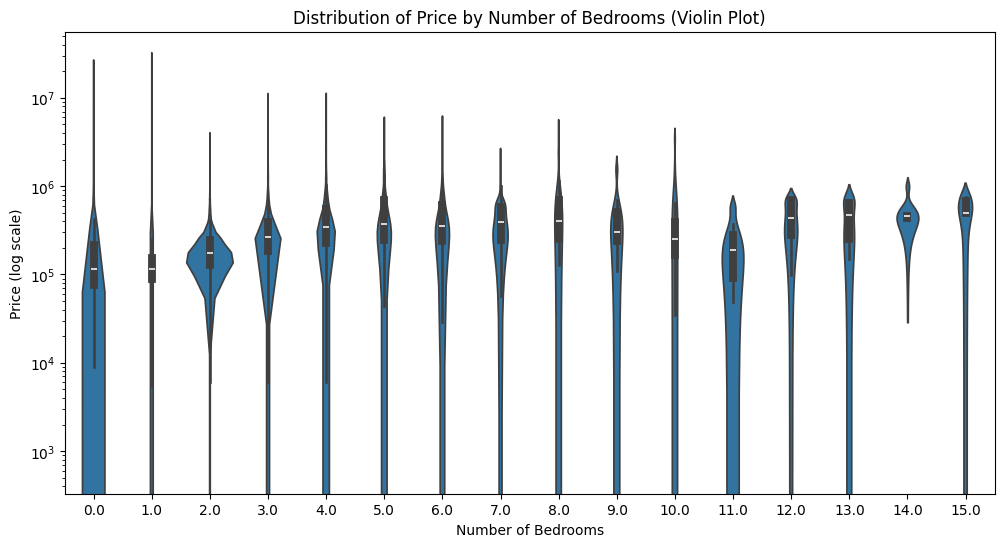

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.violinplot(data=df, x='bedrooms', y='price')
plt.title('Distribution of Price by Number of Bedrooms (Violin Plot)')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price (log scale)')
plt.yscale('log')
plt.show()

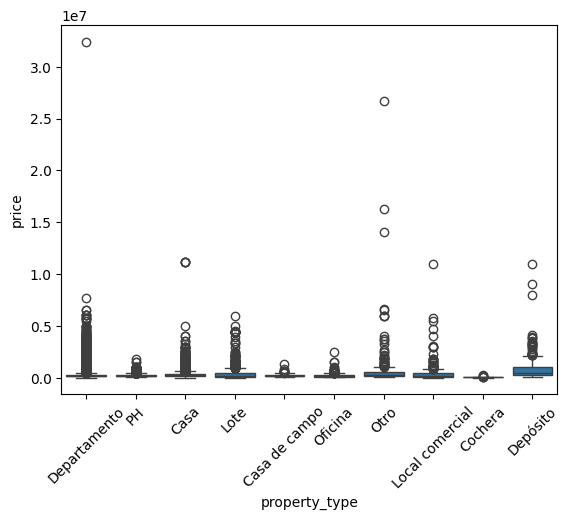

In [ ]:
# Boxplot: precio según tipo de propiedad
sns.boxplot(data=df, x="property_type", y="price")
plt.xticks(rotation=45)
# plt.yscale('log') # Set y-axis to a logarithmic scale
plt.show()

In [ ]:
# Calculate outliers using IQR and get percentage per column
numeric_cols = df.select_dtypes(include=np.number).columns

Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 3 * IQR
upper_bound = Q3 + 3 * IQR

# Identify outliers for each numerical column
outliers_count = ((df[numeric_cols] < lower_bound) | (df[numeric_cols] > upper_bound)).sum()

# Calculate percentage of outliers
outliers_percentage = (outliers_count / len(df)) * 100

print("Percentage of outliers per numerical column (using IQR):")
display(outliers_percentage.to_frame('Porcentaje de Atípicos').T)

Percentage of outliers per numerical column (using IQR):


,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
Porcentaje de Atípicos,8.287877,5.456839,0.120005,0.049775,0.326606,5.942316,2.71035,3.76858


In [ ]:
# Calculate outliers using IQR
#excluimos latitud y longitud
# Select only numeric columns for quantile calculation, excluding 'lat' and 'lon'
numeric_df = df.select_dtypes(include=np.number).drop(['lat', 'lon'], axis=1)

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

# Define bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers - apply bounds to the original dataframe, checking only specified numeric columns
outliers = df[((numeric_df < lower_bound) | (numeric_df > upper_bound)).any(axis=1)]

print("Outliers based on IQR:")
display(outliers)

Outliers based on IQR:


,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,bathrooms,surface_total,surface_covered,price,currency,title,description,property_type,operation_type
0,2019-10-17,2019-12-23,2019-10-17,-34.605880,-58.384949,Argentina,Capital Federal,San Cristobal,7.0,7.0,2.0,140.0,140.0,153000.0,USD,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,Venta
125,2019-10-17,2019-12-23,2019-10-17,-34.710146,-58.386282,Argentina,Bs.As. G.B.A. Zona Sur,Lanús,3.0,2.0,1.0,250.0,250.0,210000.0,USD,Departamentos tipo casa Centro de Lanus 2 y 3 ...,"Excelente ubicacion, pleno centro de Lanus.2 P...",PH,Venta
138,2019-10-17,9999-12-31,2019-10-17,-34.630374,-58.707596,Argentina,Bs.As. G.B.A. Zona Oeste,Ituzaingó,3.0,2.0,1.0,292.0,90.0,110000.0,USD,CASA 3 AMBIENTES SOBRE LOTE 10 X 20,ITUZAINGO NORTE: Casa tres ambientes con gara...,Casa,Venta
152,2019-10-17,2019-12-23,2019-10-17,-34.393765,-58.644893,Argentina,Bs.As. G.B.A. Zona Norte,Tigre,3.0,2.0,2.0,163.0,118.0,650000.0,USD,NORDELTA | ACQUA RIO - Excelente Departamento ...,Espectacular departamento de 3 ambientes con v...,Departamento,Venta
160,2019-10-17,2019-11-19,2019-10-17,-34.590064,-58.382945,Argentina,Capital Federal,Retiro,3.0,2.0,1.0,106.0,106.0,498000.0,USD,VENTA depto excelente vista Rio 2 dormit depen...,"LIVING/COMEDOR, 2 DORMITORIOS, 1 BAÑO COMPLETO...",Departamento,Venta
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
146612,2019-07-31,2020-01-17,2019-07-31,-34.467206,-58.858964,Argentina,Bs.As. G.B.A. Zona Norte,Pilar,4.0,3.0,3.0,220.0,220.0,270000.0,USD,VENTA DORMI DE POLO MARTINDALE CC,VENTADORMIE DE POLO MARTINDALE CCPB. living co...,Departamento,Venta
146613,2019-07-31,2019-09-04,2019-07-31,-34.467469,-58.859391,Argentina,Bs.As. G.B.A. Zona Norte,Pilar,3.0,2.0,2.0,220.0,220.0,250000.0,USD,DORMIE EN MARTINDALE C.C. - Mallmann Propiedades,PLANTA BAJA• Hall de entrada• Toilete• Living ...,Departamento,Venta
146626,2019-07-31,2020-01-17,2019-07-31,-34.933308,-58.486543,Argentina,Bs.As. G.B.A. Zona Sur,San Vicente,4.0,3.0,2.0,236.0,236.0,350000.0,USD,COUNTRY EL LAUQUEN - CASA EN ALQUILER - CANNING,ESPECTACULAR CASA EN COUNTRY CLUB EL LAUQUEN E...,Casa,Venta
146631,2019-07-31,2019-08-14,2019-07-31,-34.390502,-58.627147,Argentina,Bs.As. G.B.A. Zona Norte,Tigre,5.0,3.0,3.0,240.0,213.0,650000.0,USD,SOL EXC.VISTA VERDE Y RÍO COHERA-AMARRA-SEVICI...,Excelente Dúplex con importantes detalles de d...,Departamento,Venta


In [ ]:
# Select only numeric columns for outlier detection, excluding 'lat' and 'lon'
numeric_cols_for_outliers = df.select_dtypes(include=np.number).drop(['lat', 'lon'], axis=1).columns

Q1 = df[numeric_cols_for_outliers].quantile(0.25)
Q3 = df[numeric_cols_for_outliers].quantile(0.75)
IQR = Q3 - Q1

# Define bounds for extreme outliers (3 * IQR)
lower_bound_extreme = Q1 - 3 * IQR
upper_bound_extreme = Q3 + 3 * IQR

# Identify rows that are NOT outliers in any of the specified numeric columns
# Use the original dataframe for filtering
not_outliers = ~((df[numeric_cols_for_outliers] < lower_bound_extreme) | (df[numeric_cols_for_outliers] > upper_bound_extreme)).any(axis=1)

# Filter the dataframe to keep only rows that are not outliers
df = df[not_outliers].copy()

print(f"Original number of rows: {len(df)}")
print(f"Number of rows after removing extreme outliers: {len(df)}")

# You can now work with df

Original number of rows: 133179
Number of rows after removing extreme outliers: 133179


In [ ]:
#Graficar conteos para variables categóricas (sug: value_counts() o sns.countplot())

In [ ]:
# vemos que variables son categoricas para poder graficar
categorical_variables = df.select_dtypes(include=['object', 'category']).columns

print("Categorical variables:")
print(categorical_variables)

Categorical variables:
Index(['start_date', 'end_date', 'l1', 'l2', 'l3', 'currency', 'title',
       'description', 'property_type', 'operation_type'],
      dtype='object')


In [ ]:
df["currency"].unique()

array(['USD'], dtype=object)

Count of each grouped title:


,Count
title_grouped,
Other,94911
DEPARTAMENTO EN VENTA,4973
Departamento de 2 ambientes en Venta en Villa crespo,1604
Departamento de 3 ambientes en Venta en Almagro,1256
Departamento de 3 ambientes en Venta en Villa crespo,1146
...,...
MONOAMBIENTE DIVISIBLE A ESTRENAR PATERNAL,6
DEPARTAMENTO EN VENTA DE TRES AMBIENTES EN ACQUA RIO - NORDELTA!!,6
CABALLITO EXCELENTES PISOS CON COCHERA A ESTRENAR A MTS DEL CID CAMPEADOR,6


/tmp/ipython-input-3415003745.py:24: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


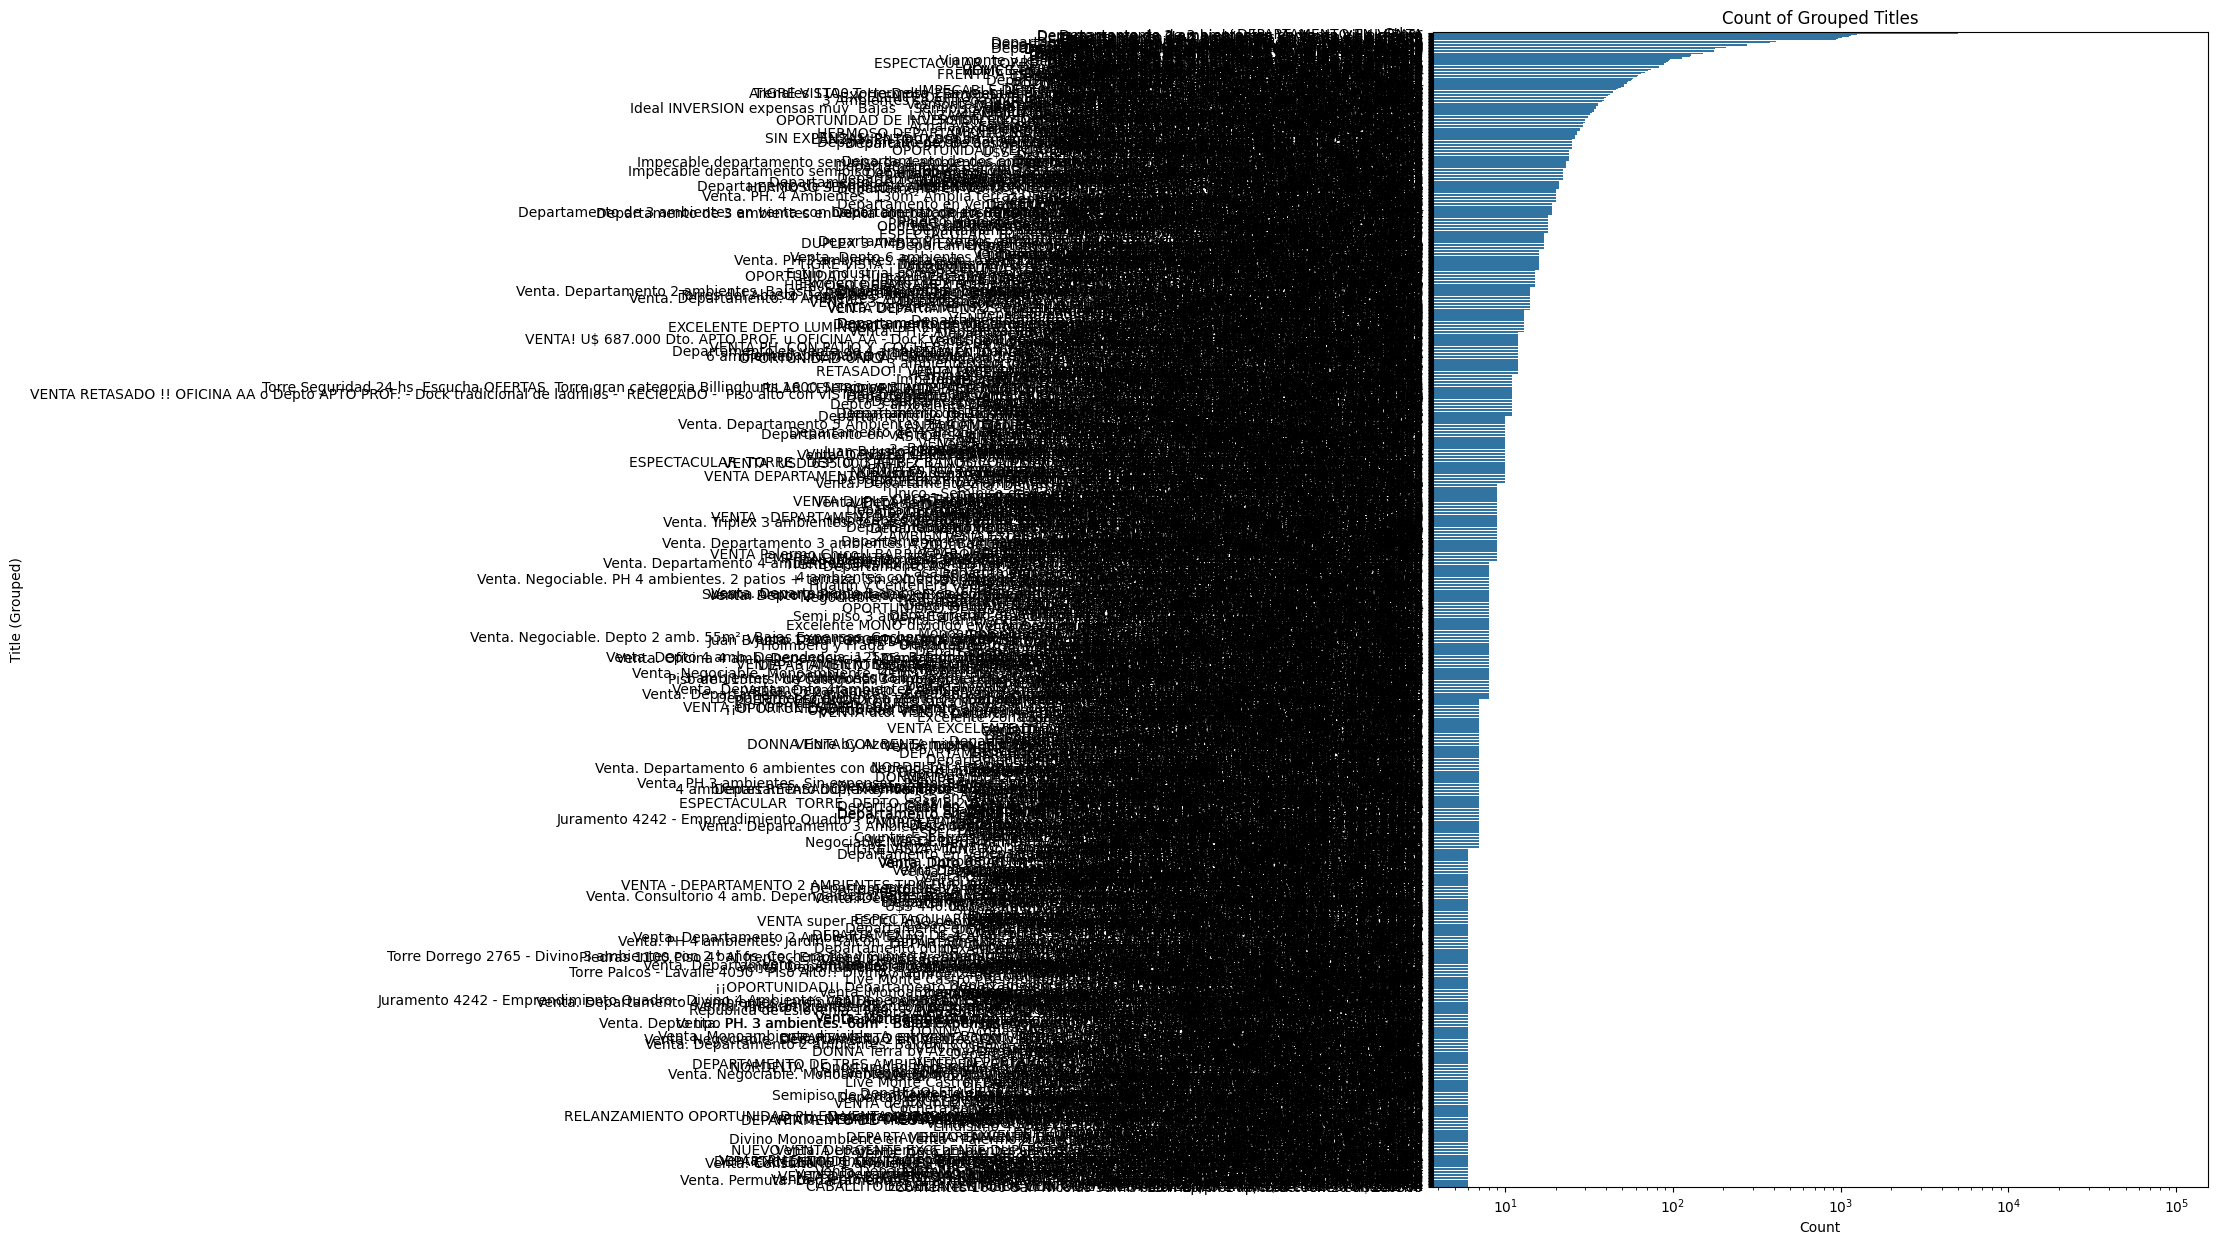

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Count the occurrences of each title
title_counts = df['title'].value_counts()


threshold = 5 #  threshold: group titles appearing less than 5 times

# Create a new column 'title_grouped'
df['title_grouped'] = df['title'].apply(lambda x: x if title_counts[x] > threshold else 'Other')

# Display the count of each grouped title in a table
print("Count of each grouped title:")
display(df['title_grouped'].value_counts().to_frame('Count'))

# Create a countplot of the grouped titles
plt.figure(figsize=(10, 15)) # Adjust figure size as needed
sns.countplot(data=df, y='title_grouped', order=df['title_grouped'].value_counts().index)
plt.title('Count of Grouped Titles')
plt.xlabel('Count')
plt.ylabel('Title (Grouped)')
plt.xscale('log') # Use a logarithmic scale for the x-axis due to wide range of counts
plt.tight_layout()
plt.show()

In [ ]:
# Count the occurrences of each description
description_counts = df['description'].value_counts()

threshold = 10 # group descriptions appearing less than 10 times

# Create a new column 'description_grouped'
df['description_grouped'] = df['description'].apply(lambda x: x if description_counts[x] > threshold else 'Other')

# Display the count of each grouped description
print("Count of each grouped description:")
display(df['description_grouped'].value_counts().to_frame('Count'))



Count of each grouped description:


,Count
description_grouped,
Other,114615
"EDIFICIO DE CATEGORIA CON MATERIALES Y ACCESORIOS DE 1RA CALIDAD- SPLIT FRIO -CALOR - EL DEPARTAMENTO CONSTA CON BAULERA. EL EDIFICIO CONTIENE GIMNASIO - SALA DE JUEGOS - SAUNA - PISCINA CON SOLARIUM - SUM CON ESPACIO VERDE Y LAUNDRY - UBICADO EN ZON ESTRATEGICA -EDIFICADO POR CONSTRUCTORA DE ALTA TRAYECTORIA - COMERCIALIZA MIGLIORISI - CORRIENTES 5500 - - Se deja constancia que las caracteristicas, medidas, expensas y superficies consignadas son aproximadas, sujetos a verificación y/o ajuste. El precio del inmueble puede ser modificado sin previo aviso. Fotos de carácter no contractual. Las unidades publicadas están sujetas a disponibilidad.",235
"Lindo departamento de 3 ambientes, con balcon corrido al frente!!! todos los ambientes super luminosos y con buena vista abierta!!! 44 m2 , dormitorios con placard, equipado con aire frio/calor en el living, expensas bajas, Ideal para vivienda, uso profesional o inversion - Apto profesional, Excelente ubicacion, a media cuadra de hospital Italiano, cerca de subte B, cerca de plaza Almagro y Parque centenario. COMERCIALIZA SUC. INMOBILIARIA MIGLIORISI AV. CORRIENTES 4599 - T.E.: 11-52734599 / 11- 52721892 - Se deja constancia que las caracteristicas, medidas, expensas y superficies consignadas son aproximadas, sujetos a verificación y/o ajuste. El precio del inmueble puede ser modificado sin previo aviso. Fotos de carácter no contractual. Las unidades publicadas están sujetas a disponibilidad.",151
"Lindo departamento de 3 ambientes c/depndencia (actualmente dormitorio) con balcon corrido al contrafrente, 78 m2 totales, super luminoso!, sistema de termotanque y calefaccion central +1 equipo de aire acc. split, cuenta con sistema levanta cortina automatico, 1 baño completo y 1 baño de servicio, cuenta con baulera de uso comun, excelente ubicacion! cerquita de todo! a mts de subte linea B (Angel Gallardo) - COMERCIALIZA SUC. INMOBILIARIA MIGLIORISI AV. CORRIENTES 4599 - T.E.: 11-52734599 / 11-52721892 / 11-52721894 - Se deja constancia que las caracteristicas, medidas, expensas y superficies consignadas son aproximadas, sujetos a verificación y/o ajuste. El precio del inmueble puede ser modificado sin previo aviso. Fotos de carácter no contractual. Las unidades publicadas están sujetas a disponibilidad.",128
"Hermoso 2 AMBIENTES al contra frente con balcon aterrazado, pisos de porcellanato, detalles de categoria mucha luz, cerca de subtes A y B y de Avdas, excelente ubicacion, apto profesional. Se deja constancia que las caracteristicas, medidas, expensas y superficies consignadas son aproximadas, sujetos a verificación y/o ajuste. El precio del inmueble puede ser modificado sin previo aviso. Fotos de carácter no contractual. Las unidades publicadas están sujetas a disponibilidad.",125
...,...
"Departamento 2 ambientes.Amplio living comedor con cocina integrada, lavadero y salida a balcón. Dormitorio. Un baño completo.El desarrollo comprende la construcción de dos torres de 19 pisos. La primera ya se encuentra entregada.La propuesta está pensada para uso familiar. Cuenta con unidades de dos y tres ambientes.Incluye amenities y servicios de alta categoría y confort, como piscina, SUM, gimnasio, solarium, laundry, parrilla, cocheras, seguridad las 24 horas, entrada y salida peatonal y vehicular, control de accesos por circuito cerrado, sistemas de detección de incendio, 3 ascensores, estacionamiento de cortesía y más.LAS MEDIDAS SON APROXIMADAS Y PROPORCIONADAS X EL PROPIETARIO y/o Estudio de Arquitectos.Esta oferta es a solo título informativo, pues para la venta de la propiedad es condición que el propietario cumplimente el tramite ante la AFIP para obtener el nro. de C.O.T.I si fuera necesario.Nucifora Propiedades S.R.L. comparte 50% de los Honorarios Inmobiliarios en todos los casos donde: a) el Vendedor/ Locador pague el porcentaje establecido segun usos y costumbres por el colegio de Martilleros de la jurisdicción correspondiente. Variacion

In [ ]:
df["operation_type"].unique()

array(['Venta'], dtype=object)

In [ ]:
#Nos quedmos unicamente con 'property_type', 'bathrooms', 'rooms'.
#No nos quedmos con start_date ni end_date dado que son fechas pero estan en formato object,
#por eso la funcion la detecta, y no consideramos currency dado que solo hay una categoria que es "USD", lo mismo con "operation_type".
#Title y description tampoco las vamos a utilizar dado que tienen muchas variables.
#descartamos descrption dado que las categorias no son representativas

Count of property type:


,Count
property_type,
Departamento,102721
Casa,14355
PH,13821
Lote,674
Oficina,635
Local comercial,275
Cochera,259
Otro,189
Depósito,178


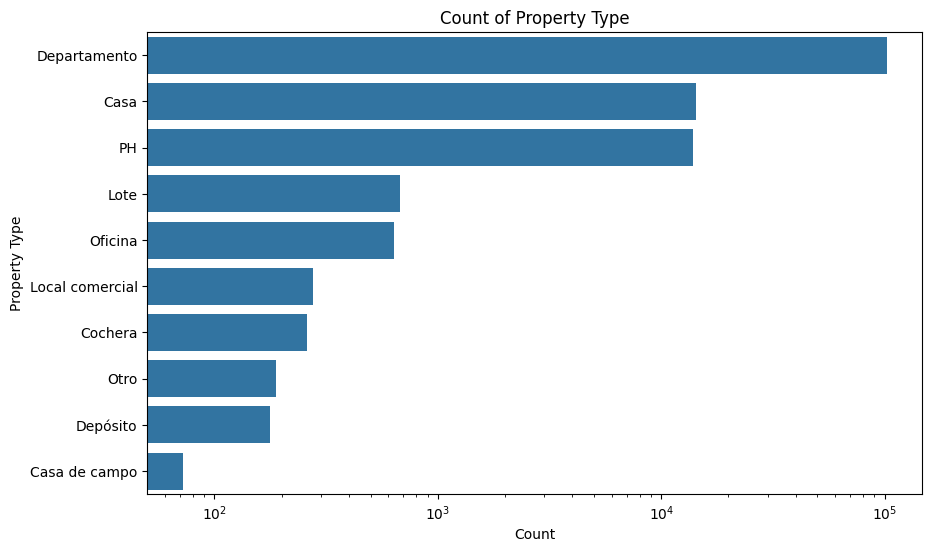

In [ ]:
# Calculate and display the count of each property type
print("Count of property type:")
property_type_counts = df['property_type'].value_counts()
display(property_type_counts.to_frame('Count'))

# Create a countplot of the property types
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y='property_type', order=property_type_counts.index)
plt.title('Count of Property Type')
plt.xlabel('Count')
plt.ylabel('Property Type')
plt.xscale('log') # Set x-axis to a logarithmic scale
plt.show()

Count of bathrooms:


,Count
bathrooms,
1.0,81065
2.0,35345
3.0,9300
4.0,2002
5.0,266


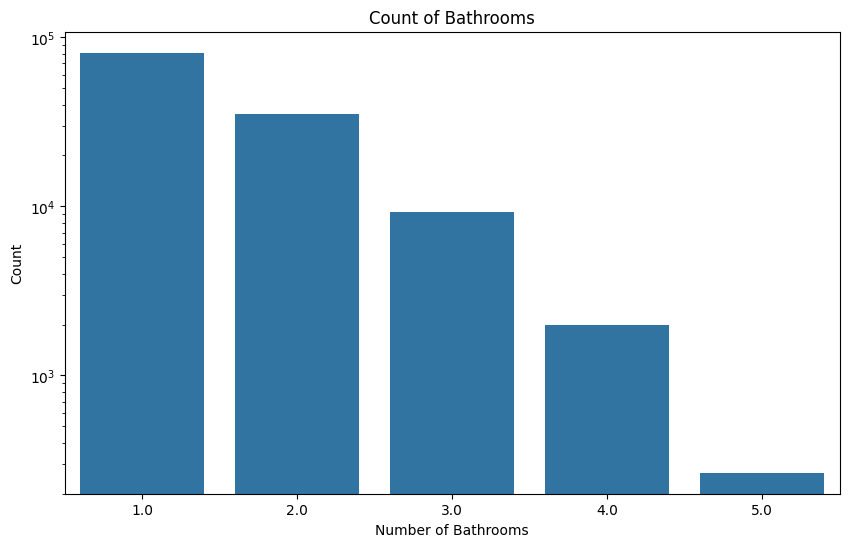

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate and display the count of each number of bathrooms
print("Count of bathrooms:")
bathrooms_counts = df['bathrooms'].value_counts().sort_index()
display(bathrooms_counts.to_frame('Count'))

# Create a countplot of the bathrooms
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='bathrooms', order=bathrooms_counts.index)
plt.title('Count of Bathrooms')
plt.xlabel('Number of Bathrooms')
plt.ylabel('Count')
plt.yscale('log') # Use a logarithmic scale for the y-axis if counts vary widely
plt.show()

Count of rooms:


,Count
rooms,
1.0,12532
2.0,40952
3.0,43383
4.0,25473
5.0,7366
6.0,2268
7.0,754
8.0,324
9.0,74


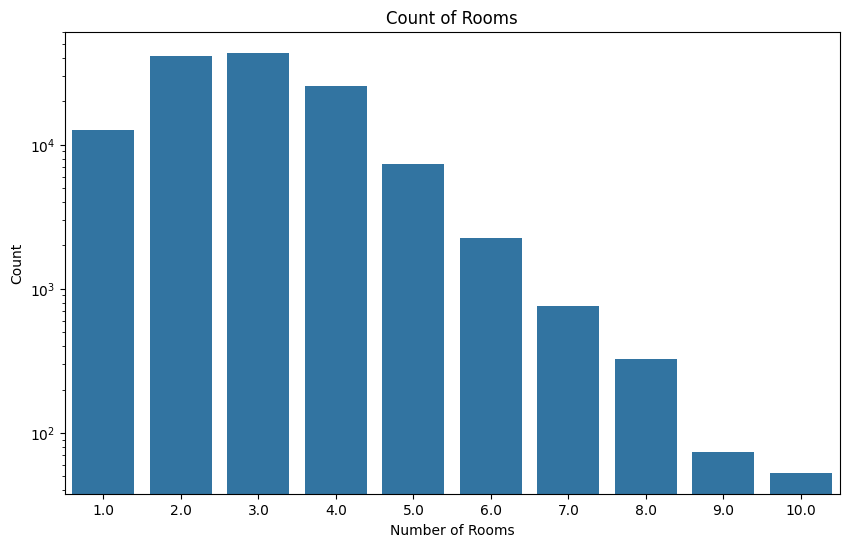

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate and display the count of each number of rooms
print("Count of rooms:")
rooms_counts = df['rooms'].value_counts().sort_index()
display(rooms_counts.to_frame('Count'))

# Create a countplot of the rooms
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='rooms', order=rooms_counts.index)
plt.title('Count of Rooms')
plt.xlabel('Number of Rooms')
plt.ylabel('Count')
plt.yscale('log') # Use a logarithmic scale for the y-axis if counts vary widely
plt.show()

Count of bedrooms:


,Count
bedrooms,
0.0,6711
1.0,49040
2.0,44065
3.0,26131
4.0,5690
5.0,992
6.0,383
7.0,143
8.0,16


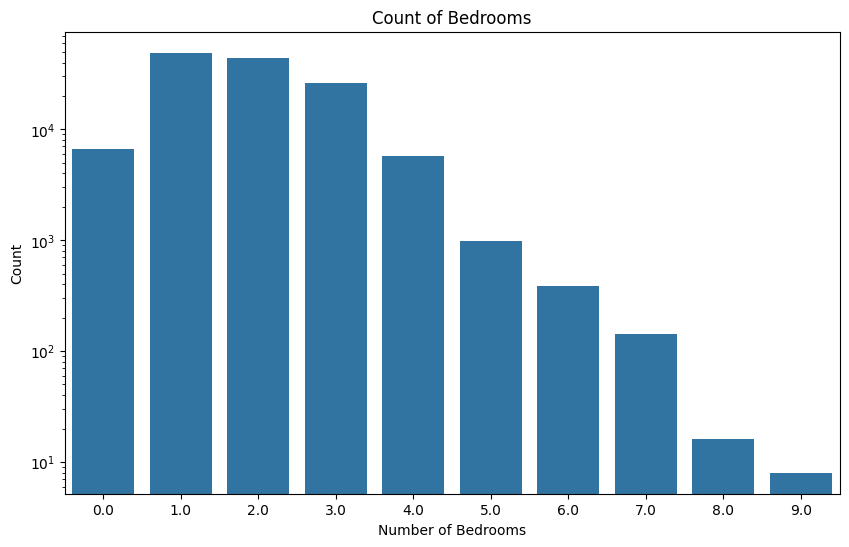

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate and display the count of each number of bedrooms
print("Count of bedrooms:")
bedrooms_counts = df['bedrooms'].value_counts().sort_index()
display(bedrooms_counts.to_frame('Count'))

# Create a countplot of the bedrooms
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='bedrooms', order=bedrooms_counts.index)
plt.title('Count of Bedrooms')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')
plt.yscale('log') # Use a logarithmic scale for the y-axis if counts vary widely
plt.show()

In [ ]:
#4.4) Relaciones entre variables
#Graficar diagramas de dispersión entre variables relevantes y el precio (sug: scatterplot(), sns.pairplot()).
#Calcular matriz de correlación y visualizar (sug: imshow o sns.heatmap()).

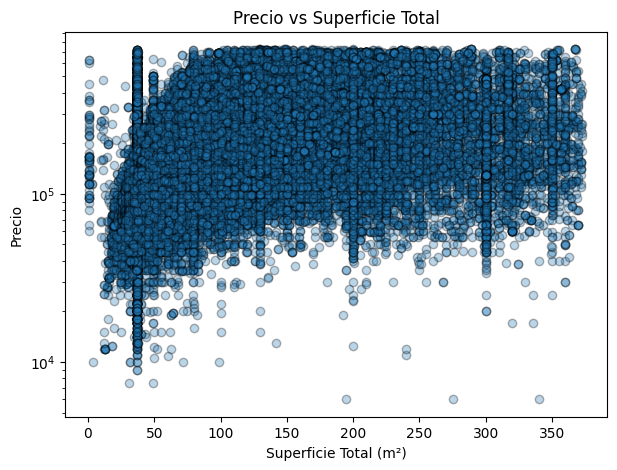

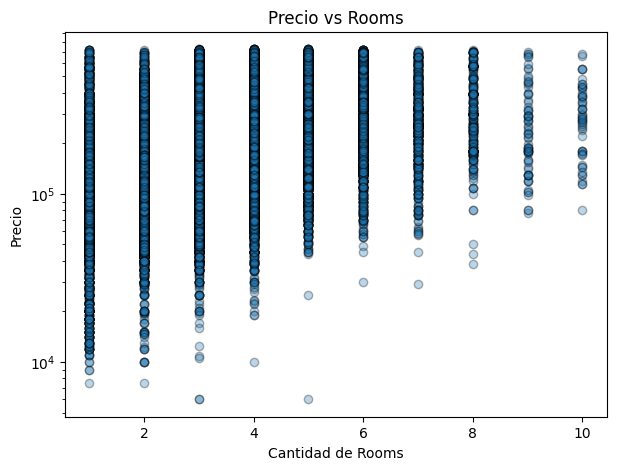

In [ ]:
# Scatter: Precio vs Superficie Total
plt.figure(figsize=(7,5))
plt.scatter(df['surface_total'], df['price'], alpha=0.3, edgecolor='k')
plt.xlabel('Superficie Total (m²)')
plt.ylabel('Precio')
plt.title('Precio vs Superficie Total')
plt.yscale('log')  # escala logarítmica para manejar outliers en precios
plt.show()

# Scatter: Precio vs Rooms
plt.figure(figsize=(7,5))
plt.scatter(df['rooms'], df['price'], alpha=0.3, edgecolor='k')
plt.xlabel('Cantidad de Rooms')
plt.ylabel('Precio')
plt.title('Precio vs Rooms')
plt.yscale('log')
plt.show()

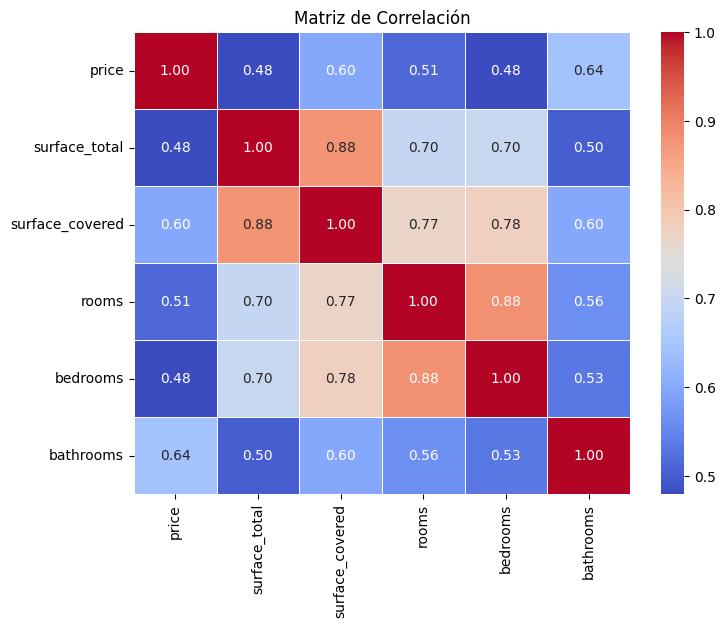

In [ ]:
# Seleccionar solo variables numéricas relevantes
num_cols = ['price', 'surface_total', 'surface_covered', 'rooms', 'bedrooms', 'bathrooms']

# Calcular la matriz de correlación (Pearson por defecto)
corr = df[num_cols].corr(method='pearson')

# Visualizar con heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

# 5. Preparar los datos para modelos de ML

- 5.1) **Selección de variables**
  - Identificar variables numéricas y categóricas.
  - Identificar si hay columnas irrelevantes o redundantes.
  - Opcional: Aplicar ingeniería de features (ej: transformaciones o nuevas variables a partir de las presentes).
  - Seleccionar un conjunto prometedor de variables predictoras.

- 5.2) **Codificación de variables categóricas**
  - Usar `OneHotEncoder` o `OrdinalEncoder`  para variables categóricas (decidir cual).

- 5.3) **Imputación de valores faltantes**
  - Imputar valores faltantes si hay. Decidir qué estrategia de imputación usar para variables numéricas y para categóricas (sug: `SimpleImputer`).

- 5.4) **Separación de datos**
  - Crear los conjuntos de entrenamiento y testeo `X_train`, `X_test`, `y_train`, `y_test` (sug: `train_test_split`).

- 5.5) **Escalado de variables numéricas**
  - Normalizar las variables numéricas (sug: `StandardScaler`).


In [ ]:
df.describe()

,created_on,lat,lon,rooms,bedrooms,bathrooms,surface_total,surface_covered,price
count,133179,124508.000000,124474.000000,133179.000000,133179.000000,127978.000000,133179.000000,133179.000000,133179.000000
mean,2019-08-04 07:30:15.934944768,-34.604275,-58.460540,2.898212,1.853010,1.476762,90.876501,74.578593,193204.604938
min,2019-01-01 00:00:00,-35.123742,-180.000000,1.000000,0.000000,1.000000,1.000000,1.000000,6000.000000
25%,2019-05-02 00:00:00,-34.626519,-58.498451,2.000000,1.000000,1.000000,49.000000,44.000000,109733.500000
50%,2019-08-01 00:00:00,-34.601201,-58.442889,3.000000,2.000000,1.000000,70.000000,62.000000,159000.000000
75%,2019-11-13 00:00:00,-34.577128,-58.409277,4.000000,3.000000,2.000000,110.000000,91.000000,243000.000000
max,2020-01-25 00:00:00,85.051129,-57.805832,10.000000,9.000000,5.000000,373.000000,300.000000,725000.000000
std,NaN,0.488463,0.504556,1.195919,1.030758,0.716661,63.112101,44.466106,121070.876137


Las variables numericas son 'lat', 'lon', 'rooms', 'bedrooms','bathrooms','surface_total', 'surface covered' y 'price'

In [ ]:
df.describe(include="all")

,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,...,surface_total,surface_covered,price,currency,title,description,property_type,operation_type,title_grouped,description_grouped
count,133179,133179,133179,124508.000000,124474.000000,133179,133179,133179,133179.000000,133179.000000,...,133179.000000,133179.000000,133179.000000,133179,133179,133179,133179,133179,133179,133179
unique,366,410,NaN,NaN,NaN,1,4,89,NaN,NaN,...,NaN,NaN,NaN,1,69299,95517,10,1,1525,725
top,2019-07-31,9999-12-31,NaN,NaN,NaN,Argentina,Capital Federal,Palermo,NaN,NaN,...,NaN,NaN,NaN,USD,DEPARTAMENTO EN VENTA,EDIFICIO DE CATEGORIA CON MATERIALES Y ACCESOR...,Departamento,Venta,Other,Other
freq,10340,23297,NaN,NaN,NaN,133179,87181,11858,NaN,NaN,...,NaN,NaN,NaN,133179,4973,235,102721,133179,94911,114615
mean,NaN,NaN,2019-08-04 07:30:15.934944768,-34.604275,-58.460540,NaN,NaN,NaN,2.898212,1.853010,...,90.876501,74.578593,193204.604938,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,2019-01-01 00:00:00,-35.123742,-180.000000,NaN,NaN,NaN,1.000000,0.000000,...,1.000000,1.000000,6000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,2019-05-02 00:00:00,-34.626519,-58.498451,NaN,NaN,NaN,2.000000,1.000000,...,49.000000,44.000000,109733.500000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,2019-08-01 00:00:00,-34.601201,-58.442889,NaN,NaN,NaN,3.000000,2.000000,...,70.000000,62.000000,159000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,2019-11-13 00:00:00,-34.577128,-58.409277,NaN,NaN,NaN,4.000000,3.000000,...,110.000000,91.000000,243000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
max,NaN,NaN,2020-01-25 00:00:00,85.051129,-57.805832,NaN,NaN,NaN,10.000000,9.000000,...,373.000000,300.000000,725000.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
print("Count of unique values for 'bedrooms':")
display(df['bedrooms'].value_counts())

print("\nCount of unique values for 'rooms':")
display(df['rooms'].value_counts())

print("\nCount of unique values for 'bathrooms':")
display(df['bathrooms'].value_counts())

Count of unique values for 'bedrooms':


,count
bedrooms,
1.0,49040
2.0,44065
3.0,26131
0.0,6711
4.0,5690
5.0,992
6.0,383
7.0,143
8.0,16



Count of unique values for 'rooms':


,count
rooms,
3.0,43383
2.0,40952
4.0,25473
1.0,12532
5.0,7366
6.0,2268
7.0,754
8.0,324
9.0,74



Count of unique values for 'bathrooms':


,count
bathrooms,
1.0,81065
2.0,35345
3.0,9300
4.0,2002
5.0,266


Teniendo en cuenta la cantidad de datos unicos sobre el total consideramos categoricas las siguientes features: l2,l3,property_type, bedrooms, bathrooms y rooms


Consideramos irrelevantes las categorias l1, currency y operation_type dado que contienen un unico dato que se repite para todas las instancias.

Los tipos de datos se pueden eficientizar convirtiendo las fechas en tipo de dato date y los numeros que no admiten float como cantidades de cuartos convertirlos en int

In [ ]:
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

In [ ]:
df['rooms'] = df['rooms'].astype(int)
df['bedrooms'] = df['bedrooms'].astype(int)


In [ ]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133179 entries, 0 to 146659
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   start_date           133179 non-null  datetime64[ns]
 1   end_date             109882 non-null  datetime64[ns]
 2   created_on           133179 non-null  datetime64[ns]
 3   lat                  124508 non-null  float64       
 4   lon                  124474 non-null  float64       
 5   l1                   133179 non-null  object        
 6   l2                   133179 non-null  object        
 7   l3                   133179 non-null  object        
 8   rooms                133179 non-null  int64         
 9   bedrooms             133179 non-null  int64         
 10  bathrooms            127978 non-null  float64       
 11  surface_total        133179 non-null  float64       
 12  surface_covered      133179 non-null  float64       
 13  price              

Las posibles variables predictoras son  l2,l3,property_type, bedrooms, bathrooms y rooms

In [ ]:
print("Unique values for 'l2':")
display(df['l2'].unique())

Unique values for 'l2':


array(['Capital Federal', 'Bs.As. G.B.A. Zona Sur',
       'Bs.As. G.B.A. Zona Norte', 'Bs.As. G.B.A. Zona Oeste'],
      dtype=object)

In [ ]:
import numpy as np
import pandas as pd

# Asegurá tipos correctos
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')

# (Opcional) Normalizar textos para evitar “Boedo” vs “boedo ” etc.
for col in ['l1', 'l2', 'l3']: # Corrected column names to lowercase
    df[col] = (df[col]
               .astype('string')
               .str.strip()
               .str.replace(r'\s+', ' ', regex=True)
               .str.title())

def impute_latlon_by_geo(df, keys_levels=[['l1','l2','l3'], ['l1','l2'], ['l1']]): # Corrected column names to lowercase
    df = df.copy()

    # imputación en cascada: l1+l2+l3 -> l1+l2 -> l1
    for keys in keys_levels:
        # promedio del grupo
        grp_means = (df.groupby(keys, dropna=False)[['lat','lon']]
                       .transform('mean'))
        # completar solo donde falte
        df['lat'] = df['lat'].fillna(grp_means['lat'])
        df['lon'] = df['lon'].fillna(grp_means['lon'])

    return df

df = impute_latlon_by_geo(df)


In [ ]:
print("Unique values for 'l3':")
display(df['l3'].unique())

Unique values for 'l3':


<StringArray>
[       'San Cristobal',                'Boedo',              'Palermo',
             'La Plata',         'Villa Crespo',     'Parque Patricios',
     'Villa Pueyrredón',                'Pilar',                'Tigre',
               'Abasto',               'Flores',                'Morón',
                'Nuñez',              'Almagro',             'Belgrano',
             'Floresta',             'Recoleta',            'Balvanera',
            'Caballito',            'Chacarita',            'San Telmo',
           'Colegiales',           'La Matanza',           'San Isidro',
           'San Miguel',           'Villa Luro',         'Barrio Norte',
          'Las Cañitas',          'San Nicolás',        'Villa Urquiza',
        'Vicente López',    'Parque Centenario',   'General San Martín',
  'Villa General Mitre',                'Lanús',            'Ituzaingó',
                 'Boca',                 'Once',               'Retiro',
            'Monserrat',           'A

In [ ]:
print("Unique values for 'property_type':")
display(df['property_type'].unique())

Unique values for 'property_type':


array(['Departamento', 'PH', 'Casa', 'Oficina', 'Lote', 'Local comercial',
       'Casa de campo', 'Otro', 'Cochera', 'Depósito'], dtype=object)

In [ ]:
#no lo cargo de nuevo

# Asegurar tipos de lat/lon
df['lat'] = pd.to_numeric(df['lat'], errors='coerce')
df['lon'] = pd.to_numeric(df['lon'], errors='coerce')

# Normalizar strings en l1, l2, l3
for col in ['l1', 'l2', 'l3']:
    df[col] = (df[col]
               .astype('string')
               .str.strip()
               .str.replace(r'\s+', ' ', regex=True)
               .str.title())

# Fechas a formato datetime
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

# Convertir a enteros donde corresponde
df['rooms'] = df['rooms'].astype(int)
df['bedrooms'] = df['bedrooms'].astype(int)

# OneHotEncoder para l2
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
l2_onehot = encoder.fit_transform(df[['l2']])

l2_onehot_df = pd.DataFrame(
    l2_onehot,
    columns=encoder.get_feature_names_out(['l2']),
    index=df.index
)

# Concatenar el one-hot encoding con df original
df = pd.concat([df, l2_onehot_df], axis=1)

# Mostrar preview
display(df.head())


,start_date,end_date,created_on,lat,lon,l1,l2,l3,rooms,bedrooms,...,title,description,property_type,operation_type,title_grouped,description_grouped,l2_Bs.As. G.B.A. Zona Norte,l2_Bs.As. G.B.A. Zona Oeste,l2_Bs.As. G.B.A. Zona Sur,l2_Capital Federal
0,2019-10-17,2019-12-23,2019-10-17,-34.605880,-58.384949,Argentina,Capital Federal,San Cristobal,7,7,...,"***Venta semipiso centro, ideal hostel*****",DESCRIPCION DE LA PROPIEDAD: Departamento de 1...,Departamento,Venta,Other,Other,0.0,0.0,0.0,1.0
1,2019-10-17,2019-11-21,2019-10-17,-34.624056,-58.412110,Argentina,Capital Federal,Boedo,2,1,...,Espectacular PH reciclado en Boedo sin expensas.,PH reciclado en Boedo a una cuadra de la plaz...,PH,Venta,Other,Other,0.0,0.0,0.0,1.0
2,2019-10-17,2019-11-01,2019-10-17,-34.593569,-58.427474,Argentina,Capital Federal,Palermo,2,1,...,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",PH,Venta,Depto.tipo casa de 2 ambientes en Venta en Pal...,"2 ambienets amplio , excelente estado , patio ...",0.0,0.0,0.0,1.0
3,2019-10-17,2019-12-23,2019-10-17,-34.581294,-58.436754,Argentina,Capital Federal,Palermo,2,1,...,COSTA RICA 5800 / PALERMO HOLLYWOOD / VENTA PH...,HERMOSO PH EN PALERMO!!!2 AMBIENTES TOTALMENTE...,PH,Venta,Other,Other,0.0,0.0,0.0,1.0
4,2019-10-17,2020-03-11,2019-10-17,-34.914194,-57.938219,Argentina,Bs.As. G.B.A. Zona Sur,La Plata,2,1,...,58 entre 1 y 2 Venta de departamento en ph.1 ...,58 entre 1 y 2 Venta de departamento en PH. P...,PH,Venta,Other,Other,0.0,0.0,1.0,0.0


In [ ]:
import pandas as pd

# Reemplazar todas las categorías que quieras agrupar en "Otros"
df["property_type_grouped"] = df["property_type"].replace({
    "Depósito": "Otros",
    "Casa de campo": "Otros",
    "Otro": "Otros" })

# Crear las variables dummies
df = pd.get_dummies(df, columns=["property_type_grouped"], prefix="prop")

print(df.filter(like="prop_").head())

   prop_Casa  prop_Cochera  prop_Departamento  prop_Local comercial  \
0      False         False               True                 False   
1      False         False              False                 False   
2      False         False              False                 False   
3      False         False              False                 False   
4      False         False              False                 False   

   prop_Lote  prop_Oficina  prop_Otros  prop_PH  
0      False         False       False    False  
1      False         False       False     True  
2      False         False       False     True  
3      False         False       False     True  
4      False         False       False     True  


In [ ]:
import pandas as pd

# Crear dummies de l3 y agregarlas al df original
df = pd.get_dummies(df, columns=["l3"], prefix="l3", drop_first=False)

# Verificar que se hayan creado
print(df.filter(like="l3_").head())


   l3_Abasto  l3_Agronomía  l3_Almagro  l3_Almirante Brown  l3_Avellaneda  \
0      False         False       False               False          False   
1      False         False       False               False          False   
2      False         False       False               False          False   
3      False         False       False               False          False   
4      False         False       False               False          False   

   l3_Balvanera  l3_Barracas  l3_Barrio Norte  l3_Belgrano  l3_Berazategui  \
0         False        False            False        False           False   
1         False        False            False        False           False   
2         False        False            False        False           False   
3         False        False            False        False           False   
4         False        False            False        False           False   

   ...  l3_Villa General Mitre  l3_Villa Lugano  l3_Villa Luro  \
0 

In [ ]:
# Impute missing 'bathrooms' based on the mean number of bathrooms per number of rooms
df['bathrooms'] = df.groupby('rooms')['bathrooms'].transform(lambda x: x.fillna(x.mean()))

df['bathrooms'] = df['bathrooms'].astype(int)

# Display the percentage of null values again to check imputation
null_percentages = df.isnull().sum() / len(df) * 100
print("porcentaje_nulos_x_columna after bathroom imputation")
display(null_percentages.to_frame('Porcentaje de Nulos').T)

porcentaje_nulos_x_columna after bathroom imputation


,start_date,end_date,created_on,lat,lon,l1,l2,rooms,bedrooms,bathrooms,...,l3_Villa General Mitre,l3_Villa Lugano,l3_Villa Luro,l3_Villa Ortuzar,l3_Villa Pueyrredón,l3_Villa Real,l3_Villa Riachuelo,l3_Villa Santa Rita,l3_Villa Soldati,l3_Villa Urquiza
Porcentaje de Nulos,0.0,17.492998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import pandas as pd
from sklearn.impute import SimpleImputer

# Supongamos que ya cargaste tu DataFrame como 'df'

# Seleccionamos las columnas a imputar
cols_to_impute = ['surface_total', 'surface_covered']

# Creamos el imputador
imputer = SimpleImputer(strategy='median')

# Aplicamos el imputador
df[cols_to_impute] = imputer.fit_transform(df[cols_to_impute])

# Volvé a calcular después de imputar
null_percentages = df.isnull().mean() * 100

# Mostralo en forma de tabla transpuesta
display(null_percentages.to_frame('Porcentaje de Nulos').T)

,start_date,end_date,created_on,lat,lon,l1,l2,rooms,bedrooms,bathrooms,...,l3_Villa General Mitre,l3_Villa Lugano,l3_Villa Luro,l3_Villa Ortuzar,l3_Villa Pueyrredón,l3_Villa Real,l3_Villa Riachuelo,l3_Villa Santa Rita,l3_Villa Soldati,l3_Villa Urquiza
Porcentaje de Nulos,0.0,17.492998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
import pandas as pd

# Convert date columns to datetime objects if they aren't already
df['start_date'] = pd.to_datetime(df['start_date'], errors='coerce')
df['end_date'] = pd.to_datetime(df['end_date'], errors='coerce')

# Calculate the time difference (duration) for non-null end_dates
duration = df['end_date'] - df['start_date']

# Calculate the average duration, excluding NaT (Not a Time) values
average_duration = duration.mean()

# Impute missing 'end_date' values by adding the average duration to the corresponding 'start_date'
df['end_date'].fillna(df['start_date'] + average_duration, inplace=True)

# Display the percentage of null values again to check imputation
null_percentages = df.isnull().sum() / len(df) * 100
print("porcentaje_nulos_x_columna after end_date imputation")
display(null_percentages.to_frame('Porcentaje de Nulos').T)

porcentaje_nulos_x_columna after end_date imputation


/tmp/ipython-input-2232699373.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['end_date'].fillna(df['start_date'] + average_duration, inplace=True)


,start_date,end_date,created_on,lat,lon,l1,l2,rooms,bedrooms,bathrooms,...,l3_Villa General Mitre,l3_Villa Lugano,l3_Villa Luro,l3_Villa Ortuzar,l3_Villa Pueyrredón,l3_Villa Real,l3_Villa Riachuelo,l3_Villa Santa Rita,l3_Villa Soldati,l3_Villa Urquiza
Porcentaje de Nulos,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Columnas que vamos a escalar (solo features numéricas)
cols_to_scale = ['surface_total', 'surface_covered']

# Scaler solo para features
scaler_X = StandardScaler()

# Escalar X (features numéricas)
df[cols_to_scale] = scaler_X.fit_transform(df[cols_to_scale])


In [ ]:
from sklearn.model_selection import train_test_split

y = df['price']
X = df.drop(columns=['price'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)



# 6. Entrenamiento


- 6.1) **Probar al menos 4 modelos distintos**
  - Ej: Regresión lineal simple (`LinearRegression`), Ridge Regression (`Ridge`), Lasso Regression (`Lasso`).
  - Probar modelos con regresión polinomial usando `PolynomialFeatures`.
  - Ir siempre de lo más simple a lo más complejo.

- 6.2) **Evaluar y comparar**
  - Evaluar los modelos **solo** en el conjunto de entrenamiento mediante validación cruzada usando `cross_val_score`.

In [ ]:
## LINEAR Y RIDGE

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Variables
numerical_features = ['rooms','l3_Abasto', 'l3_Agronomía', 'l3_Almagro', 'l3_Almirante Brown', 'l3_Avellaneda', 'l3_Balvanera', 'l3_Barracas', 'l3_Barrio Norte', 'l3_Belgrano', 'l3_Berazategui', 'l3_Boca', 'l3_Boedo', 'l3_Caballito', 'l3_Catalinas', 'l3_Cañuelas', 'l3_Centro / Microcentro', 'l3_Chacarita', 'l3_Coghlan', 'l3_Colegiales', 'l3_Congreso', 'l3_Constitución', 'l3_Escobar', 'l3_Esteban Echeverría', 'l3_Ezeiza', 'l3_Florencio Varela', 'l3_Flores', 'l3_Floresta', 'l3_General Rodríguez', 'l3_General San Martín', 'l3_Hurlingham', 'l3_Ituzaingó', 'l3_José C Paz', 'l3_La Matanza', 'l3_La Plata', 'l3_Lanús', 'l3_Las Cañitas', 'l3_Liniers', 'l3_Lomas De Zamora', 'l3_Malvinas Argentinas', 'l3_Marcos Paz', 'l3_Mataderos', 'l3_Merlo', 'l3_Monserrat', 'l3_Monte Castro', 'l3_Moreno', 'l3_Morón', 'l3_Nuñez', 'l3_Once', 'l3_Palermo', 'l3_Parque Avellaneda', 'l3_Parque Centenario', 'l3_Parque Chacabuco', 'l3_Parque Chas', 'l3_Parque Patricios', 'l3_Paternal', 'l3_Pilar', 'l3_Pompeya', 'l3_Presidente Perón', 'l3_Puerto Madero', 'l3_Quilmes', 'l3_Recoleta', 'l3_Retiro', 'l3_Saavedra', 'l3_San Cristobal', 'l3_San Fernando', 'l3_San Isidro', 'l3_San Miguel', 'l3_San Nicolás', 'l3_San Telmo', 'l3_San Vicente', 'l3_Tigre', 'l3_Tres De Febrero', 'l3_Tribunales', 'l3_Velez Sarsfield', 'l3_Versalles', 'l3_Vicente López', 'l3_Villa Crespo', 'l3_Villa Del Parque', 'l3_Villa Devoto', 'l3_Villa General Mitre', 'l3_Villa Lugano', 'l3_Villa Luro', 'l3_Villa Ortuzar', 'l3_Villa Pueyrredón', 'l3_Villa Real', 'l3_Villa Riachuelo', 'l3_Villa Santa Rita', 'l3_Villa Soldati', 'l3_Villa Urquiza',
                      'surface_covered', 'l2_Bs.As. G.B.A. Zona Norte',
    'l2_Bs.As. G.B.A. Zona Oeste',
    'l2_Bs.As. G.B.A. Zona Sur',
    'l2_Capital Federal', 'prop_Casa',	'prop_Cochera',	'prop_Departamento',	'prop_Local comercial',	'prop_Lote',	'prop_Oficina',
                      'prop_Otros',	'prop_PH','lat','lon']

# Preprocesador: numéricas passthrough + OneHot para categóricas
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features)
    ],
    remainder='drop'
)

# Transformar train y test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Preprocessing applied. Processed data is ready for model training.")
print("Shape of X_train_processed:", X_train_processed.shape)
print("Shape of X_test_processed:", X_test_processed.shape)

# === Linear Regression ===
lin_reg = LinearRegression()
lin_reg.fit(X_train_processed, y_train)
y_pred_lin = lin_reg.predict(X_test_processed)

rmse_lin = np.sqrt(mean_squared_error(y_test, y_pred_lin))
r2_lin   = r2_score(y_test, y_pred_lin)

print("\n=== Linear Regression ===")
print("RMSE test:", round(rmse_lin, 4))
print("R² test :", round(r2_lin, 4))

# === Ridge Regression ===
ridge_reg = Ridge(alpha=1.0, random_state=42)
ridge_reg.fit(X_train_processed, y_train)
y_pred_ridge = ridge_reg.predict(X_test_processed)

rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge   = r2_score(y_test, y_pred_ridge)

print("\n=== Ridge Regression ===")
print("RMSE test:", round(rmse_ridge, 4))
print("R² test :", round(r2_ridge, 4))


Preprocessing applied. Processed data is ready for model training.
Shape of X_train_processed: (106543, 105)
Shape of X_test_processed: (26636, 105)

=== Linear Regression ===
RMSE test: 75867.8203
R² test : 0.6082

=== Ridge Regression ===
RMSE test: 75868.6151
R² test : 0.6082


In [ ]:
## LASSO
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
import numpy as np

# Variables
numerical_features = ['rooms',
                      'surface_covered', 'l2_Bs.As. G.B.A. Zona Norte',
    'l2_Bs.As. G.B.A. Zona Oeste',
    'l2_Bs.As. G.B.A. Zona Sur',
    'l2_Capital Federal']

# Preprocesador
preprocessor = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', numerical_features)
    ],
    remainder='drop'
)

# Transformar datos
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

# Entrenar Lasso con alpha=0.001
lasso = Lasso(alpha=0.001, selection='random',
              max_iter=200000, tol=1e-3, random_state=42)
lasso.fit(X_train_processed, y_train)

# Predicciones
y_pred = lasso.predict(X_test_processed)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
nonzero = np.sum(lasso.coef_ != 0)

print("=== Lasso Regression (alpha=0.001) ===")
print("RMSE test:", round(rmse, 4))
print("R² test :", round(r2, 4))
print("Coeficientes distintos de 0:", nonzero)
print("Intercepto:", lasso.intercept_)
print("Coeficientes:", lasso.coef_)


=== Lasso Regression (alpha=0.001) ===
RMSE test: 91585.6248
R² test : 0.429
Coeficientes distintos de 0: 6
Intercepto: 140142.91774245678
Coeficientes: [ 13710.91469422  62203.61376956  12244.32232838 -64273.06965798
 -35431.67161817  31320.37131936]


In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Features numéricas "reales"
numeric_real = ['rooms', 'surface_covered', 'lat', 'lon']

# Features categóricas ya codificadas (dummies)
categorical_dummies = [col for col in X_train.columns if col.startswith(('l2_', 'l3_', 'prop_'))]

# Preprocesador: polinomiales en numéricas, passthrough en dummies
preprocessor = ColumnTransformer(
    transformers=[
        ('poly', PolynomialFeatures(degree=2, include_bias=False), numeric_real),
        ('dummies', 'passthrough', categorical_dummies)
    ],
    remainder='drop'
)

# Transformar train y test
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Shape de X_train con polinomiales:", X_train_processed.shape)

# Ajustar modelo lineal
poly_reg = LinearRegression()
poly_reg.fit(X_train_processed, y_train)

# Predicciones
y_pred = poly_reg.predict(X_test_processed)

# Métricas
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)

print(f"RMSE en test: {rmse:,.0f} USD")
print(f"R² en test : {r2:.4f}")



Shape de X_train con polinomiales: (106543, 115)
RMSE en test: 71,076 USD
R² en test : 0.6561


# 7. Ajuste fino



- 7.1) **Buscar los mejores hiperparámetros**
  - Para los modelos con hiperparámetros (como `alpha`  y/o `degree`), hacer un ajuste fino por validación cruzada (sug: `GridSearch` o `RandomizedSearch`).
  - Elegir el modelo final basandose en las métricas de validación cruzada. Hacer un gráfico de barras comparando el RMSE de validación de los modelos comparados.
  - Especificar cuál es el modelo elegido, sus hiperparámetros y variables de entrada (*features*).

Mejor alpha (Ridge): {'ridge__alpha': np.float64(12.915496650148826)}
Mejor RMSE (CV): 75270.08275371662


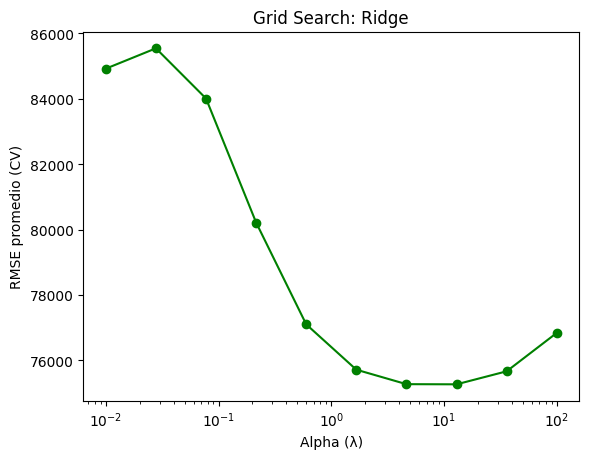

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
import numpy as np
import matplotlib.pyplot as plt

pipeline_ridge = Pipeline([
    ("prep", preprocessor),
    ("ridge", Ridge(max_iter=200000, random_state=42))
])

param_grid_ridge = {
    "ridge__alpha": np.logspace(-2, 2, 10)  # 0.001 a 1000
}

grid_search_ridge = GridSearchCV(
    pipeline_ridge,
    param_grid_ridge,
    cv=3,  # menos folds
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

grid_search_ridge.fit(X_train, y_train)

print("Mejor alpha (Ridge):", grid_search_ridge.best_params_)
print("Mejor RMSE (CV):", -grid_search_ridge.best_score_)

alphas = param_grid_ridge["ridge__alpha"]
mean_rmse = -grid_search_ridge.cv_results_["mean_test_score"]

plt.semilogx(alphas, mean_rmse, marker="o", color="green")
plt.xlabel("Alpha (λ)")
plt.ylabel("RMSE promedio (CV)")
plt.title("Grid Search: Ridge")
plt.show()

best_pipe_ridge = grid_search_ridge.best_estimator_

Fitting 2 folds for each of 4 candidates, totalling 8 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.317e+14, tolerance: 7.796e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.278e+14, tolerance: 7.812e+11
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.316e+14, tolerance: 7.796e

Mejor alpha (Lasso): {'lasso__alpha': 0.3}
Mejor RMSE (CV): 86643.63522398556


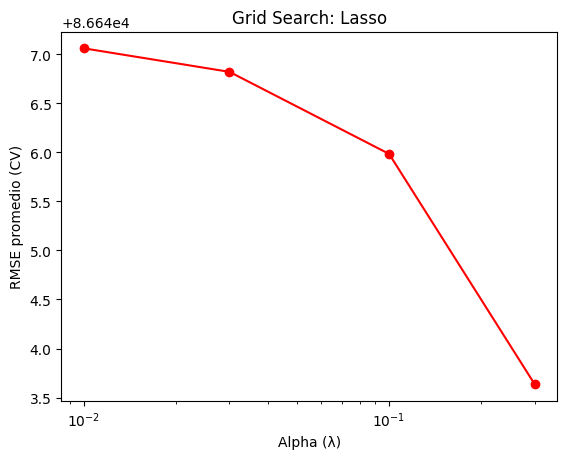

In [ ]:
# LASSO
from sklearn.linear_model import Lasso
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from tempfile import mkdtemp

# cache para reutilizar transformaciones y acelerar
_cache_dir = mkdtemp()

pipeline_lasso = Pipeline([
    ("prep", preprocessor),                           # tu preprocesador
    ("svd", TruncatedSVD(n_components=115, random_state=42)),  # ↓ dimensión (ajustable), corrected n_components
    ("scale", StandardScaler()),                      # escala para que Lasso converga
    ("lasso", Lasso(
        max_iter=3000,        # menos iteraciones
        tol=1e-3,             # tolerancia más laxa → converge antes
        selection="random",   # coord. descent aleatorio acelera
        random_state=42
    ))
], memory=_cache_dir)

param_grid_lasso = {
    "lasso__alpha": [0.01, 0.03, 0.1, 0.3]  # menos puntos → mucho más rápido
}

grid_search_lasso = GridSearchCV(
    pipeline_lasso,
    param_grid_lasso,
    cv=2,                                # 2 folds para recortar tiempo
    scoring="neg_root_mean_squared_error",
    n_jobs=1,                            # evitar procesos en paralelo (RAM)
    pre_dispatch=1,
    verbose=1
)

grid_search_lasso.fit(X_train, y_train)

print("Mejor alpha (Lasso):", grid_search_lasso.best_params_)
print("Mejor RMSE (CV):", -grid_search_lasso.best_score_)

alphas = param_grid_lasso["lasso__alpha"]
mean_rmse = -grid_search_lasso.cv_results_["mean_test_score"]

plt.semilogx(alphas, mean_rmse, marker="o", color="red")
plt.xlabel("Alpha (λ)")
plt.ylabel("RMSE promedio (CV)")
plt.title("Grid Search: Lasso")
plt.show()

best_pipe_lasso = grid_search_lasso.best_estimator_

In [ ]:
## POLINOMIAL
from sklearn.preprocessing import PolynomialFeatures, FunctionTransformer
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV
from sklearn.compose import ColumnTransformer
import numpy as np

# Features numéricas "reales" (reducidas)
numeric_real_poly = ['rooms', 'surface_covered']

# Dummies ya creadas
categorical_dummies = [col for col in X_train.columns if col.startswith(('l2_', 'l3_', 'prop_'))]

# Preprocesador: polinomiales SOLO aquí + dummies
preprocessor_poly = ColumnTransformer(
    transformers=[
        ('poly', PolynomialFeatures(include_bias=False, interaction_only=True), numeric_real_poly),
        ('dummies', 'passthrough', categorical_dummies)
    ],
    remainder='drop',
    sparse_threshold=1.0   # intenta mantener sparse para ahorrar memoria
)

pipeline_poly = Pipeline([
    ("prep", preprocessor_poly),                                  # ← NO volvemos a aplicar PolynomialFeatures
    ("to32", FunctionTransformer(lambda X: X.astype(np.float32))),# ← baja uso de RAM
    ("lin", LinearRegression())
])

# OJO: ahora el parámetro es el interno del ColumnTransformer
param_grid_poly = {
    "prep__poly__degree": [1, 2,3]
}

grid_search_poly = GridSearchCV(
    pipeline_poly,
    param_grid_poly,
    cv=2,                                   # menos folds
    scoring="neg_root_mean_squared_error",
    n_jobs=1,                               # evita matar RAM por procesos en paralelo
    pre_dispatch=1,
    verbose=1
)

grid_search_poly.fit(X_train, y_train)

print("Mejor degree (Polynomial):", grid_search_poly.best_params_)
print("Mejor RMSE (CV):", -grid_search_poly.best_score_)

best_pipe_poly = grid_search_poly.best_estimator_


Fitting 2 folds for each of 3 candidates, totalling 6 fits
Mejor degree (Polynomial): {'prep__poly__degree': 2}
Mejor RMSE (CV): 74536.02140015483


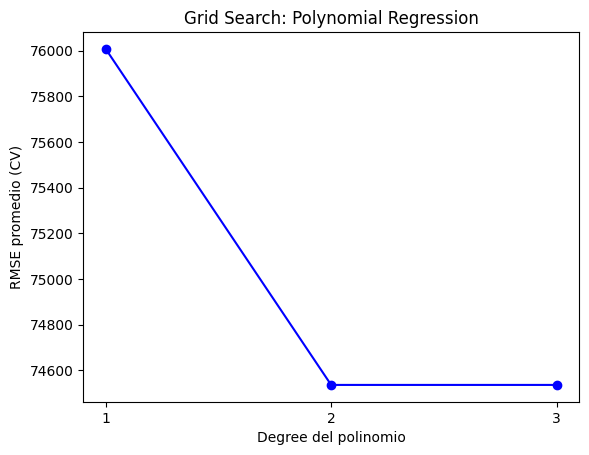

In [ ]:
degrees = param_grid_poly["prep__poly__degree"] # Corrected key here
mean_rmse = -grid_search_poly.cv_results_["mean_test_score"]

plt.plot(degrees, mean_rmse, marker="o", color="blue")
plt.xlabel("Degree del polinomio")
plt.ylabel("RMSE promedio (CV)")
plt.title("Grid Search: Polynomial Regression")
plt.xticks(degrees)  # para que muestre 1, 2, 3 en el eje x
plt.show()

best_pipe_poly = grid_search_poly.best_estimator_

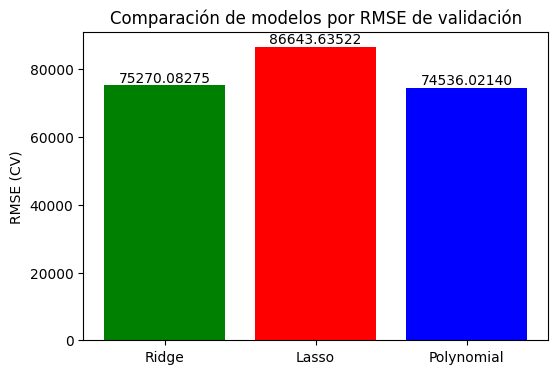

Modelo elegido: Polynomial
Hiperparámetros del modelo elegido: {'prep__poly__degree': 2}
Nº de features usadas: 104
Ejemplos de features: ['poly__rooms' 'poly__surface_covered' 'poly__rooms surface_covered'
 'dummies__l2_Bs.As. G.B.A. Zona Norte'
 'dummies__l2_Bs.As. G.B.A. Zona Oeste'
 'dummies__l2_Bs.As. G.B.A. Zona Sur' 'dummies__l2_Capital Federal'
 'dummies__prop_Casa' 'dummies__prop_Cochera' 'dummies__prop_Departamento'
 'dummies__prop_Local comercial' 'dummies__prop_Lote'
 'dummies__prop_Oficina' 'dummies__prop_Otros' 'dummies__prop_PH'
 'dummies__l3_Abasto' 'dummies__l3_Agronomía' 'dummies__l3_Almagro'
 'dummies__l3_Almirante Brown' 'dummies__l3_Avellaneda']


In [ ]:
# === Tabla resumen final ===
summary = pd.DataFrame({
    "Modelo": ["Ridge", "Lasso", "Polynomial"],
    "RMSE_CV": [
        -grid_search_ridge.best_score_,   # mejor RMSE CV de Ridge
        -grid_search_lasso.best_score_,   # mejor RMSE CV de Lasso
        -grid_search_poly.best_score_     # mejor RMSE CV de Polynomial
    ]
})

# Gráfico de barras (menor RMSE es mejor)
plt.figure(figsize=(6,4))
plt.bar(summary["Modelo"], summary["RMSE_CV"], color=["green","red","blue"])
for i, v in enumerate(summary["RMSE_CV"]):
    plt.text(i, v, f"{v:.5f}", ha="center", va="bottom")
plt.ylabel("RMSE (CV)")
plt.title("Comparación de modelos por RMSE de validación")
plt.show()

# Identificar modelo ganador
winner_idx = summary["RMSE_CV"].idxmin()
winner_name = summary.loc[winner_idx, "Modelo"]
print(f"Modelo elegido: {winner_name}")

# Hiperparámetros y pipeline del ganador
if winner_name == "Ridge":
    best_params = grid_search_ridge.best_params_
    best_pipe = best_pipe_ridge
elif winner_name == "Lasso":
    best_params = grid_search_lasso.best_params_
    best_pipe = best_pipe_lasso
else:
    best_params = grid_search_poly.best_params_
    best_pipe = best_pipe_poly

print("Hiperparámetros del modelo elegido:", best_params)

# Variables de entrada (features) usadas por el preprocesador
try:
    feat_names = best_pipe.named_steps["prep"].get_feature_names_out()
    print(f"Nº de features usadas: {len(feat_names)}")
    # Muestra algunas para verificar
    print("Ejemplos de features:", feat_names[:20])
except Exception as e:
    print("No pude recuperar automáticamente los nombres de features:", e)


# 8. Testeo

- 8.1) **Finalmente, evaluar el modelo final en el conjunto de testeo**
  - Calcular el RMSE del modelo final (en test) y visualizar predicciones vs valores reales en un scatterplot.
  - ¿Cuáles fueron las features más importantes?, ¿Pueden hacer alguna interpretación?

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import numpy as np

# Elegir el modelo final según lo que ganara en CV
best_model = best_pipe
best_model.fit(X_train, y_train)

# Predicciones en test
y_pred = best_model.predict(X_test)

# RMSE y R² en test
rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
r2_test = r2_score(y_test, y_pred)

print(f"RMSE en test: {rmse_test:.4f}")
print(f"R² en test:   {r2_test:.4f}")


RMSE en test: 75296.5253
R² en test:   0.6141


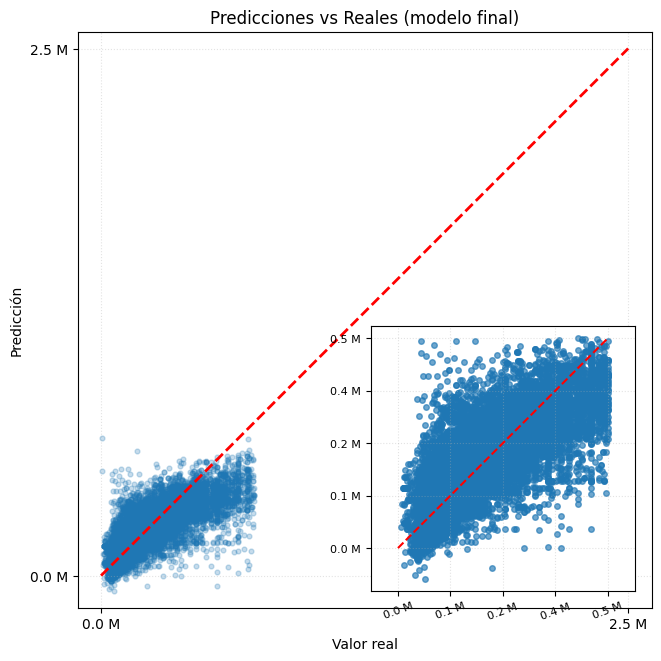

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, MultipleLocator, MaxNLocator
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

x = np.asarray(y_test).ravel()
y = np.asarray(y_pred).ravel()

# --- formateador en millones ---
fmtM = FuncFormatter(lambda v, pos: f"{v/1e6:.1f} M")

# límites "lindos"
hi_main = max(x.max(), y.max())
step_main = 2.5e6                           # separaciones del eje principal
hi_main = np.ceil(hi_main/step_main)*step_main

# figura
fig, ax = plt.subplots(figsize=(6.5,6.5), constrained_layout=True)
ax.scatter(x, y, alpha=0.25, s=12)
ax.plot([0, hi_main], [0, hi_main], "r--", lw=2)
ax.set_xlim(0, hi_main); ax.set_ylim(0, hi_main)
ax.axis("equal"); ax.grid(True, linestyle=":", alpha=0.35)
ax.set_xlabel("Valor real"); ax.set_ylabel("Predicción")
ax.set_title("Predicciones vs Reales (modelo final)")

# --- eje X/Y principal: ticks y formato ---
ax.xaxis.set_major_locator(MultipleLocator(step_main))
ax.yaxis.set_major_locator(MultipleLocator(step_main))
ax.xaxis.set_major_formatter(fmtM)
ax.yaxis.set_major_formatter(fmtM)
# ax.ticklabel_format(style='plain', axis='both', useOffset=False)  # quita 1e7

# --- inset: zoom al 98% superior con pocos ticks ---
p_hi = 0.98
lim_hi = np.quantile(np.r_[x, y], p_hi)
step_ins = lim_hi/4                           # 4 divisiones
axins = inset_axes(ax, width="46%", height="46%", loc="lower right", borderpad=1.2)
mask = (x <= lim_hi) & (y <= lim_hi)
axins.scatter(x[mask], y[mask], alpha=0.65, s=16)
axins.plot([0, lim_hi], [0, lim_hi], "r--", lw=1.5)
axins.set_xlim(0, lim_hi); axins.set_ylim(0, lim_hi)
axins.axis("equal"); axins.grid(True, linestyle=":", alpha=0.35)

axins.xaxis.set_major_locator(MultipleLocator(step_ins))
axins.yaxis.set_major_locator(MultipleLocator(step_ins))
axins.xaxis.set_major_formatter(fmtM)
axins.yaxis.set_major_formatter(fmtM)
for lab in axins.get_xticklabels():
    lab.set_rotation(20); lab.set_fontsize(8)
for lab in axins.get_yticklabels():
    lab.set_fontsize(8)

In [ ]:
def print_top_features(pipeline, top=10):
    last_step_name = None
    for name, step in reversed(pipeline.named_steps.items()):
        if hasattr(step, "coef_"):
            last_step_name = name
            estimator = step
            break
    if last_step_name is None:
        print("No se encontraron coeficientes.")
        return

    coefs = estimator.coef_.ravel()

    if "poly" in pipeline.named_steps:
        base_names = pipeline.named_steps["prep"].get_feature_names_out()
        feat_names = pipeline.named_steps["poly"].get_feature_names_out(base_names)
    else:
        feat_names = pipeline.named_steps["prep"].get_feature_names_out()

    coef_df = pd.DataFrame({
        "Feature": feat_names,
        "Coef": coefs,
        "AbsCoef": np.abs(coefs)
    }).sort_values("AbsCoef", ascending=False)

    print(f"\nTop {top} features más importantes:")
    print(coef_df.head(top))

print_top_features(best_model, top=10)


Top 10 features más importantes:
                        Feature           Coef        AbsCoef
73    dummies__l3_Puerto Madero  255990.000000  255990.000000
50      dummies__l3_Las Cañitas  119816.460938  119816.460938
1         poly__surface_covered  106471.125000  106471.125000
95     dummies__l3_Villa Lugano  -94535.031250   94535.031250
13          dummies__prop_Otros   86059.062500   86059.062500
18  dummies__l3_Almirante Brown   73992.359375   73992.359375
7            dummies__prop_Casa  -72448.187500   72448.187500
23         dummies__l3_Belgrano   72139.617188   72139.617188
75         dummies__l3_Recoleta   71933.367188   71933.367188
90    dummies__l3_Vicente López   64116.390625   64116.390625


El modelo alcanza  R² = 0.6141 y RMSE ≈75296.5253. Explica alrededor del 61% de la variabilidad del precio, razonable para datos inmobiliarios con alta dispersión. Sobre el gráfico, se puede ver que los puntos se concentran en valores bajos y predice por debajo del valor real en las propiedades caras. Esto sugiere que hay un sesgo por cola derecha. En relación a los features principales se observa que predominan la ubicación de los mismos (l3) y el tipo de propiedad. Las variables que se muestran son l3_Puerto Madero, l3 Las Cañitas,surface covered y el tipo de propiedad, indican que la ubicación, los metros de la propiedas y el tipo, son lo que que aumentan el precio.